## Prepocessing text

In [1]:
pip install pandas numpy nltk scikit-learn tensorflow keras


In [2]:
import shutil
import nltk

# Hapus cache NLTK agar bisa mengunduh ulang
shutil.rmtree("/root/nltk_data", ignore_errors=True)

# Unduh ulang package yang dibutuhkan
nltk.download("punkt")
nltk.download("stopwords")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
import requests

# URL untuk daftar stopwords bahasa Indonesia
stopwords_url = "https://raw.githubusercontent.com/stopwords-iso/stopwords-id/master/stopwords-id.txt"

# Ambil daftar stopwords dari URL
response = requests.get(stopwords_url)
indonesian_stopwords = set(response.text.split("\n"))


In [4]:
import re
import string
import pandas as pd
import nltk
import os
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import RegexpTokenizer

# Tentukan direktori NLTK secara eksplisit untuk menghindari error
nltk.data.path.append(os.path.expanduser("~/nltk_data"))

# Download stopwords dan tokenizer jika belum ada
nltk.download('stopwords')
nltk.download('punkt')

# Load dataset
df = pd.read_csv("/content/sample_data/mobile_legends_reviews_cleaned1.csv")

# Pilih hanya kolom ulasan dan hapus data kosong
df = df[['content']].dropna()

# Daftar kata slang untuk normalisasi
slang_dict = {
    "gk": "gak", "tdk": "tidak", "bgt": "banget", "tp": "tapi", "krn": "karena",
    "sm": "sama", "dgn": "dengan", "pls": "tolong", "lg": "lagi", "mn": "mana",
    "jd": "jadi", "utk": "untuk", "sy": "saya", "sdh": "sudah", "hrs": "harus",
    "moonton": "Moonton", "ml": "Mobile Legends", "gw": "saya", "gua":"saya", "lag": "lambat",
    "ajg": "anjing", "ngasal": "asal-asalan", "ngasih": "memberi", "ban": "banned",
    "nyusahin": "susah", "ngetrol": "kacau", "ngetroll": "kacau", "kesel":"kesal","ping": "sinyal"
}

try:
    indonesian_stopwords = set(stopwords.words("indonesian"))
except:
    nltk.download("stopwords")
    # Jika stopwords tidak ditemukan, gunakan daftar dari sumber lain
    stopwords_url = "https://raw.githubusercontent.com/stopwords-iso/stopwords-id/master/stopwords-id.txt"
    response = requests.get(stopwords_url)
    indonesian_stopwords = set(response.text.split("\n"))

def clean_text_nltk(text):
    # 1. Lowercasing
    text = text.lower()

    # 2. Hapus URL
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # 3. Hapus angka dan tanda baca
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenizer tanpa masalah tanda baca
    tokenizer = RegexpTokenizer(r"\w+")
    words = tokenizer.tokenize(text)

    # 5. Normalisasi kata slang
    words = [slang_dict[word] if word in slang_dict else word for word in words]

    # 6. Hapus stopwords
    words = [word for word in words if word not in indonesian_stopwords]

    # Gabungkan kembali menjadi teks bersih
    return " ".join(words)

# Terapkan preprocessing ke setiap ulasan
df["cleaned_text"] = df["content"].astype(str).apply(clean_text_nltk)

# Tampilkan beberapa hasil preprocessing
df.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,content,cleaned_text
0,Aku turunkan rating bintang nya. Tolong pelaku...,turunkan rating bintang nya tolong pelaku chea...
1,Game nya diperbarui lagi lah! Enak enak main r...,game nya diperbarui enak enak main rank reset²...
2,Kondisi lag saat di tengah game sering banget ...,kondisi lambat game banget jumpai cheat bug ba...
3,"Montonnnnn, gimana sih. Gak sekali dua kali pa...",montonnnnn gimana sih gak kali pas tengahtenga...
4,Sama saja kasih skin tapi dibuat kalah terus. ...,kasih skin kalah musuh dikasih musuh musuh ber...


## Labelling

In [5]:
from textblob import TextBlob
from textblob.sentiments import NaiveBayesAnalyzer
import nltk

# Download NaiveBayesAnalyzer untuk TextBlob jika belum ada
nltk.download('movie_reviews')
nltk.download('punkt')

def get_sentiment_textblob(text):
    analysis = TextBlob(text)
    score = analysis.sentiment.polarity
    if score > 0:
        return "positif"
    elif score < 0:
        return "negatif"
    else:
        return "netral"

# Terapkan ke dataset
df["sentiment"] = df["cleaned_text"].apply(get_sentiment_textblob)

# Lihat hasil pertama
df.head()

[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,content,cleaned_text,sentiment
0,Aku turunkan rating bintang nya. Tolong pelaku...,turunkan rating bintang nya tolong pelaku chea...,negatif
1,Game nya diperbarui lagi lah! Enak enak main r...,game nya diperbarui enak enak main rank reset²...,negatif
2,Kondisi lag saat di tengah game sering banget ...,kondisi lambat game banget jumpai cheat bug ba...,negatif
3,"Montonnnnn, gimana sih. Gak sekali dua kali pa...",montonnnnn gimana sih gak kali pas tengahtenga...,negatif
4,Sama saja kasih skin tapi dibuat kalah terus. ...,kasih skin kalah musuh dikasih musuh musuh ber...,negatif


In [6]:
print(df["sentiment"].value_counts())


sentiment
negatif    6119
netral     2104
positif    1777
Name: count, dtype: int64


Distribusi Kelas Negatif sebanyak 6119 sentimen

Kelas Netral sebanyak 2104 sentimen

Kelas Positif sebanyak 1777 sentimen

In [7]:
from sklearn.preprocessing import LabelEncoder

# Inisialisasi Label Encoder
label_encoder = LabelEncoder()

# Encoding label sentimen (negatif = 0, netral = 1, positif = 2)
df["sentiment_encoded"] = label_encoder.fit_transform(df["sentiment"])

# Cek hasil encoding
print(df[["sentiment", "sentiment_encoded"]].head())

# Mapping hasil encoding agar bisa digunakan kembali nanti
sentiment_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Mapping Sentimen:", sentiment_mapping)


  sentiment  sentiment_encoded
0   negatif                  0
1   negatif                  0
2   negatif                  0
3   negatif                  0
4   negatif                  0
Mapping Sentimen: {'negatif': 0, 'netral': 1, 'positif': 2}


## Eksplorasi data

Terdapat 54.41% sentimen negatif, 28.15% sentimen netral dan 17.44% sentimen positif untuk applikasi game mobile legend

<ipython-input-8-37d5b21dbac4>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=["red", "gray", "green"])


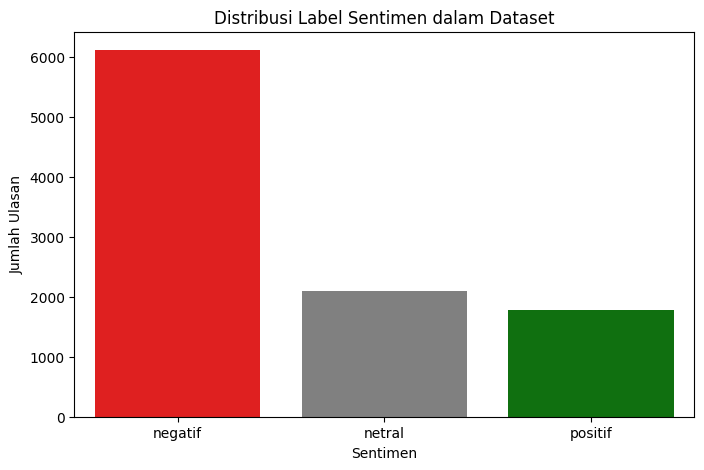


Contoh Ulasan Negatif:
['game jelek ulasan bagus kasih tim seimbang emang kalah kali kasih tim mudah ga mati matian mainnya rank legend classic serasa ranked ranked serasa mpl susahnya mashaallah pake bangettt tolong ulasan timnya bagus bermain akun akun ilang match tim seimbang tolong seimbangkan tim', 'kapasitas game meragukan nya disepanjang musim problem lambat freeze crash hero berjalan sinyal merah delay nya tombol perintah gerakan hero kondisi smartphone sepeerti ram internal memory tersedia ruang sinyal stabil senantiasa penuh server nya rusak kartu sim nya pakai kondisi', 'kasih tim bener napa su kasih tim dark sistem bngst² banget bug', 'dark sistem parah banget tim ga sesuaikadang² jaringan bagus tibatiba lambat tolong sesuaikan sistem matchmaking kasih tim sesuai', 'dark sistem nya kalok perbaiki sistem match pertandingan nya kalok pindah game sebelah tolong pertandingan perebutan role main kali kalah trs pemain nya ego nya tinggi² game nya bagus tolong perbaiki sistem mat

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cek distribusi label sentimen
sentiment_counts = df["sentiment"].value_counts()

# 2. Visualisasi distribusi sentimen
plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=["red", "gray", "green"])
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Ulasan")
plt.title("Distribusi Label Sentimen dalam Dataset")
plt.show()

# 3. Tampilkan beberapa contoh ulasan berdasarkan label sentimen
print("\nContoh Ulasan Negatif:")
print(df[df["sentiment"] == "negatif"]["cleaned_text"].sample(5, random_state=42).tolist())

print("\nContoh Ulasan Netral:")
print(df[df["sentiment"] == "netral"]["cleaned_text"].sample(5, random_state=42).tolist())

print("\nContoh Ulasan Positif:")
print(df[df["sentiment"] == "positif"]["cleaned_text"].sample(5, random_state=42).tolist())

# 4. Hitung proporsi masing-masing label dalam persentase
total_reviews = len(df)
sentiment_percentage = (sentiment_counts / total_reviews) * 100

print("\nProporsi Label Sentimen dalam Dataset (%):")
print(sentiment_percentage)


Sentimen pada kelas negatif sebanyak 61.19%, kelas netral 21.04%, dan kelas positif 17.77%

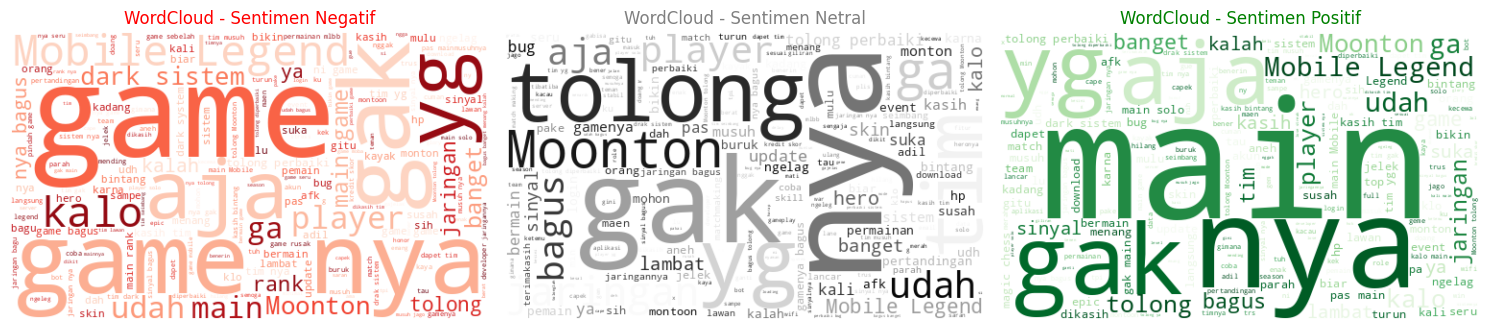

In [9]:
from wordcloud import WordCloud

# Pisahkan teks berdasarkan kategori sentimen
text_negatif = " ".join(df[df["sentiment"] == "negatif"]["cleaned_text"].dropna())
text_netral = " ".join(df[df["sentiment"] == "netral"]["cleaned_text"].dropna())
text_positif = " ".join(df[df["sentiment"] == "positif"]["cleaned_text"].dropna())

# Buat WordCloud untuk tiap kategori
wordcloud_negatif = WordCloud(width=500, height=300, background_color="white", colormap="Reds").generate(text_negatif)
wordcloud_netral = WordCloud(width=500, height=300, background_color="white", colormap="gray").generate(text_netral)
wordcloud_positif = WordCloud(width=500, height=300, background_color="white", colormap="Greens").generate(text_positif)

# Plot WordCloud
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(wordcloud_negatif, interpolation="bilinear")
ax[0].set_title("WordCloud - Sentimen Negatif", fontsize=12, color="red")
ax[0].axis("off")

ax[1].imshow(wordcloud_netral, interpolation="bilinear")
ax[1].set_title("WordCloud - Sentimen Netral", fontsize=12, color="gray")
ax[1].axis("off")

ax[2].imshow(wordcloud_positif, interpolation="bilinear")
ax[2].set_title("WordCloud - Sentimen Positif", fontsize=12, color="green")
ax[2].axis("off")

plt.tight_layout()
plt.show()


1. WordCloud Sentimen Negatif (Merah)

Kata yang dominan: "game", "gamenya", "aja", "jaringan", "udah", "bot".

Kata seperti "jaringan" dan "bot" mengindikasikan keluhan tentang masalah teknis seperti koneksi atau sistem permainan.
Kata "udah" dan "kalah" bisa menunjukkan rasa frustrasi pemain terhadap pengalaman bermain yang kurang memuaskan.

2. WordCloud Sentimen Netral (Abu-abu)
Kata yang dominan:

Kata dominan: "tolong", "gak", "saya", "Moonton", "udahh".

Kata "tolong" menunjukkan bahwa banyak pemain meminta perbaikan atau perubahan pada game.
"Moonton" (developer Mobile Legends) sering disebut, mungkin dalam konteks saran atau kritik yang lebih netral.
"gak" (tidak) mungkin digunakan dalam konteks berbagai pendapat, baik yang positif maupun negatif.

3. WordCloud Sentimen Positif (Hijau)
Kata yang dominan:

Kata yang paling dominan: "main", "gak", "nya", "Mobile Legend", "bagus", "Moonton".

Kata "main" dan "gak" menandakan pemain aktif berbicara tentang pengalaman bermain.
"bagus" dan "Moonton" menunjukkan apresiasi terhadap aspek tertentu dari game.
"tim" dan "player" menunjukkan diskusi seputar pengalaman bermain dalam tim, yang bisa berarti kerja sama yang baik atau pengalaman menyenangkan.

Kesimpulan:
1. Kritik atau keluhan utama (Negatif) tampaknya berfokus pada masalah jaringan, sistem game, dan pengalaman bermain game yang kurang memuaskan.

2. Netral mengandung lebih banyak seperti permintaan atau kritik yang bersifat saran

3. Komentar positif menyoroti pengalamn bermain, kualitas bermain, dan apresiasi terhadap Moontoon

          positif  negatif  total  % Positif  % Negatif
Gameplay     1472     4168   5640  26.099291  73.900709
Performa      362     1208   1570  23.057325  76.942675
Grafik         35      145    180  19.444444  80.555556


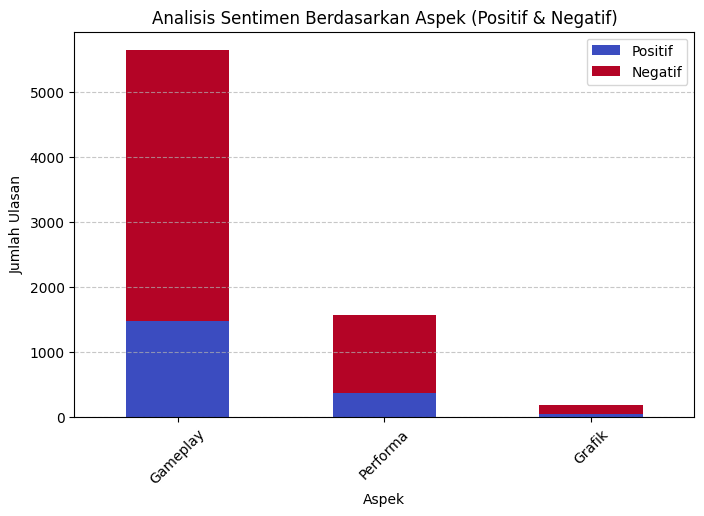

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Kamus kata per aspek
aspects = {
    "Gameplay": {"hero", "skill", "main", "tim", "mode", "rank", "match"},
    "Performa": {"lag", "bug", "koneksi", "sinyal", "lemot", "crash", "error", "hang"},
    "Grafik": {"tampilan", "animasi", "efek", "keren", "visual", "desain"}
}

# Inisialisasi dictionary untuk menyimpan jumlah sentimen per aspek
aspect_sentiment_counts = {aspect: {"positif": 0, "negatif": 0, "total": 0} for aspect in aspects.keys()}

# Loop melalui setiap review
for review, sentiment in zip(df["cleaned_text"].dropna(), df["sentiment"]):
    words = set(review.lower().split())  # Tokenisasi sederhana menggunakan split()

    for aspect, keywords in aspects.items():
        if any(word in words for word in keywords):  # Cek apakah ada kata kunci aspek dalam review
            if sentiment in ["positif", "negatif"]:  # Hanya hitung positif & negatif
                aspect_sentiment_counts[aspect][sentiment] += 1
                aspect_sentiment_counts[aspect]["total"] += 1

# Konversi ke DataFrame untuk visualisasi
aspect_df = pd.DataFrame.from_dict(aspect_sentiment_counts, orient="index")

# Hitung persentase sentimen per aspek
aspect_df["% Positif"] = (aspect_df["positif"] / aspect_df["total"] * 100).fillna(0)
aspect_df["% Negatif"] = (aspect_df["negatif"] / aspect_df["total"] * 100).fillna(0)

# Tampilkan hasil dalam tabel
print(aspect_df)

# Visualisasi Hasil Analisis Sentimen Berdasarkan Aspek
fig, ax = plt.subplots(figsize=(8, 5))
aspect_df[["positif", "negatif"]].plot(kind="bar", stacked=True, ax=ax, colormap="coolwarm")

plt.title("Analisis Sentimen Berdasarkan Aspek (Positif & Negatif)")
plt.xlabel("Aspek")
plt.ylabel("Jumlah Ulasan")
plt.legend(["Positif", "Negatif"])
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


1. Gameplay
Total ulasan: 5.640

Sentimen Positif: 1.472 (26.10%)

Sentimen Negatif: 4.168 (73.90%)

Analisis:

Gampelay merupakan aspek yang paling banyak dibahas dibandingkan dengan aspek lain. Mayoritas ulasan (73.90%) yang bersifat negatif, menunjukkan banyaknya keluhan mengenai sistem permainan, keseimbangan hero, matchmaking, atau mekanisme dalam game.

Terdapat 26.10% ulasan yang positif, mengindikasikan pemain tetap menikmati gameplay-nya tetapi jumlahnya lebih sedikit dibandingkan dengan yang memberi kritik.

2. Performa
Total ulasan: 1.570

Sentimen Positif: 362 (23.06%)

Sentimen Negatif: 1.208 (76.94%)

Analisis:

Performa juga menjadi sumber keluhan besar dengan 76.94% ulasan negatif.
Kemungkinan besar, masalah yang sering dikeluhkan berkaitan dengan lag, koneksi jaringan, bug, atau optimasi game yang kurang baik.

Hanya 23.06% ulasan yang positif, artinya hanya sebagian kecil pemain yang puas dengan performa game.

3. Grafik

Total ulasan: 180

Sentimen Positif: 35 (19.44%)

Sentimen Negatif: 145 (80.56%)

Analisis:

Grafik adalah aspek dengan jumlah ulasan paling sedikit, yang menunjukkan bahwa mayoritas pemain lebih peduli pada gameplay dan performa dibandingkan aspek visual.

80.56% ulasan negatif, yang kemungkinan besar disebabkan oleh kritik terhadap kualitas grafis, perbedaan tampilan antara perangkat high-end dan low-end, atau efek visual yang kurang memuaskan.

Hanya 19.44% ulasan positif, menandakan hanya sebagian kecil pemain yang merasa grafik game sudah cukup baik.

Kesimpulan:

1. Gameplay dan Performa adalah dua aspek utama yang paling banyak dikritik.

Mayoritas ulasan negatif terhadap gameplay mungkin terkait mekanisme game, balancing, atau sistem matchmaking.
Performa buruk juga menjadi masalah utama, dengan kemungkinan keluhan tentang lag, koneksi server, atau bug.

2. Grafik adalah aspek yang paling sedikit dibahas, tetapi memiliki persentase negatif tertinggi.

Ini menunjukkan bahwa meskipun grafik bukan prioritas utama pemain, mereka yang membahasnya cenderung kurang puas.

3. Secara keseluruhan, tingkat sentimen negatif lebih tinggi dibanding positif di semua aspek.

Ini menunjukkan bahwa banyak pemain Mobile Legends merasa ada banyak hal yang perlu diperbaiki dalam game, terutama dari segi gameplay dan performa.

## Data Splitting dan Ekstraksi fitur

In [11]:
!pip install --upgrade numpy gensim

  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)


In [12]:
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from gensim.models import Word2Vec


In [13]:
# Pisahkan fitur (X) dan label (y)
X = df["cleaned_text"]
y = df["sentiment_encoded"]

# Skema 1 & 2: 80% Train, 20% Test
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(X, y, test_size=0.2, random_state=42)

# Skema 3: 70% Train, 30% Test
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(X, y, test_size=0.3, random_state=42)


**Ekstraksi Fitur TF-IDF**

In [14]:
# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=3000)  # Ambil 5000 fitur terbaik
X_train_80_tfidf = tfidf_vectorizer.fit_transform(X_train_80)
X_test_20_tfidf = tfidf_vectorizer.transform(X_test_20)

X_train_70_tfidf = tfidf_vectorizer.fit_transform(X_train_70)
X_test_30_tfidf = tfidf_vectorizer.transform(X_test_30)


**Ekstraksi Fitur Word2Vec**

In [15]:
# Tokenisasi untuk Word2Vec
X_tokenized = [text.split() for text in X]

# Training Word2Vec model
word2vec_model = Word2Vec(sentences=X_tokenized, vector_size=50, window=10, min_count=2, workers=4)
word2vec_model.train(X_tokenized, total_examples=len(X_tokenized), epochs=10)

# Fungsi untuk mengonversi teks ke vektor Word2Vec (rata-rata embedding kata)
def get_word2vec_vector(text):
    words = text.split()
    word_vectors = [word2vec_model.wv[word] for word in words if word in word2vec_model.wv]
    if len(word_vectors) == 0:
        return np.zeros(100)  # Jika tidak ada kata yang cocok
    return np.mean(word_vectors, axis=0)

# Konversi X_train dan X_test ke Word2Vec
X_train_80_w2v = np.array([get_word2vec_vector(text) for text in X_train_80])
X_test_20_w2v = np.array([get_word2vec_vector(text) for text in X_test_20])

X_train_70_w2v = np.array([get_word2vec_vector(text) for text in X_train_70])
X_test_30_w2v = np.array([get_word2vec_vector(text) for text in X_test_30])


#Modelling

**SVM + TF-IDF (80/20)**

In [16]:
from sklearn.metrics import classification_report, accuracy_score

# SVM + TF-IDF (80/20)
svm_model = SVC(kernel="linear", C=3, random_state=42)  # C lebih besar
svm_model.fit(X_train_80_tfidf, y_train_80)
y_pred_svm = svm_model.predict(X_test_20_tfidf)
print("SVM + TF-IDF (80/20):")
print(classification_report(y_test_20, y_pred_svm))
print("Training Accuracy:", accuracy_score(y_train_80, svm_model.predict(X_train_80_tfidf)))
print("Testing Accuracy:", accuracy_score(y_test_20, y_pred_svm))


SVM + TF-IDF (80/20):
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1224
           1       0.93      0.97      0.95       439
           2       0.90      0.86      0.88       337

    accuracy                           0.95      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.95      0.95      0.95      2000

Training Accuracy: 0.992375
Testing Accuracy: 0.9515


1. Kelas 0 (Negatif):

Precision (0.97): 97% dari prediksi negatif benar, artinya model jarang salah mengklasifikasikan sentimen negatif.

Recall (0.97): 97% dari total data negatif benar diklasifikasikan, menunjukkan model sangat baik dalam menangkap sentimen negatif.

F1-score (0.97): Perpaduan precision dan recall menunjukkan model hampir sempurna dalam mengenali sentimen negatif.

2. Kelas 1 (Netral):

Precision (0.93): Model cukup baik dalam mengidentifikasi sentimen netral.

Recall (0.97): Hampir semua data netral diklasifikasikan dengan benar.

F1-score (0.95): Model cukup stabil dalam mengenali sentimen netral.

3. Kelas 2 (Positif)

Precision (0.90): Ada beberapa prediksi positif yang salah.

Recall (0.86): Model hanya berhasil menangkap 86% dari total data positif, menunjukkan ada beberapa data positif yang diklasifikasikan sebagai netral atau negatif.

F1-score (0.88): Performanya lebih rendah dibanding kelas lain, menandakan model kurang optimal dalam menangkap sentimen positif.

kesimpulan:

1. Model sangat baik dalam mengenali sentimen negatif.

2. Model cukup akurat dalam mendeteksi sentimen netral.

3. Model kurang optimal dalam mengenali sentimen positif, mungkin karena jumlah data positif lebih sedikit atau karena TF-IDF kurang menangkap makna kata-kata positif.

**XGBoost + TF-IDF (80/20)**

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# XGBoost + TF-IDF (Salah satu model terbaik untuk klasifikasi teks)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_estimators=50)
xgb_model.fit(X_train_80_tfidf, y_train_80)
y_pred_xgb = xgb_model.predict(X_test_20_tfidf)

print(" XGBoost + TF-IDF (80/20):")
print(classification_report(y_test_20, y_pred_xgb))
print("Training Accuracy:", accuracy_score(y_train_80, xgb_model.predict(X_train_80_tfidf)))
print("Testing Accuracy:", accuracy_score(y_test_20, y_pred_xgb))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:56:52] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


 XGBoost + TF-IDF (80/20):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1224
           1       0.94      0.99      0.96       439
           2       0.96      0.89      0.93       337

    accuracy                           0.97      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.97      0.97      0.97      2000

Training Accuracy: 0.993
Testing Accuracy: 0.9695


Kelas 0 (Negatif):

Precision (0.98): Model hampir tidak melakukan kesalahan dalam mengklasifikasikan sentimen negatif.

Recall (0.98): Model mampu menangkap hampir semua data dengan sentimen negatif.

F1-score (0.98): Performa model sangat stabil dalam mendeteksi sentimen negatif.

Kelas 1 (Netral):

Precision (0.94): Model cukup baik dalam mengidentifikasi sentimen netral.

Recall (0.99): Model sangat baik dalam menangkap data sentimen netral, hanya sedikit yang salah klasifikasi.

F1-score (0.96): Model bekerja sangat baik dalam mengenali sentimen netral.

Kelas 2 (Positif):

Precision (0.96): Model cukup akurat dalam mengklasifikasikan sentimen positif.

Recall (0.89): Model masih mengalami kesulitan menangkap semua data positif.

F1-score (0.93): Performa cukup stabil, tetapi masih ada ruang perbaikan.

Kesimpulan:
1. Model sangat baik dalam mengenali sentimen negatif dan netral.

2. Recall untuk kelas positif masih lebih rendah dibandingkan kelas lain, artinya ada beberapa data positif yang masih diklasifikasikan ke kelas lain.

Kesimpulan kedua model diatas:

XGBoost lebih unggul dibanding SVM, terutama dalam:

Akurasi lebih tinggi (96,95%)
Lebih akurat dalam mendeteksi sentimen positif

Recall untuk kelas positif meningkat dari 86% (SVM) menjadi 89% (XGBoost)

1. XGBoost dengan TF-IDF menunjukkan performa lebih baik dibandingkan SVM, dengan peningkatan akurasi dan stabilitas prediksi.

2. Model memiliki performa hampir sempurna untuk kelas negatif dan netral
3. Masih ada sedikit kesalahan dalam mendeteksi sentimen positif (recall 89%), yang bisa diperbaili.

# Melakukan training model lainnya (Pendekatan Deep learning)

**GRU Embedding (80/20)**

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Hyperparameter
vocab_size = 2000  # Jumlah kata unik yang dipertimbangkan dalam Tokenizer
embedding_dim = 50  # Dimensi vektor embedding (bisa 50, 100, 200, dll)
max_length = 50  # Panjang maksimal setiap review
oov_token = "<OOV>"  # Token untuk kata yang tidak dikenal

# Tokenisasi Data
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(df["cleaned_text"])

# Konversi teks ke dalam bentuk sequence
X_seq = tokenizer.texts_to_sequences(df["cleaned_text"])
X_pad = pad_sequences(X_seq, maxlen=max_length, padding="post", truncating="post")

# Konversi label ke array numpy
y = df["sentiment_encoded"].values

# Split Data (80% Training, 20% Testing)
X_train_gru, X_test_gru, y_train_gru, y_test_gru = train_test_split(X_pad, y, test_size=0.2, random_state=42)

# Model GRU
model_gru = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    GRU(64, return_sequences=True),
    GRU(32),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(3, activation="softmax")  # 3 kelas sentimen
])

# Compile Model
model_gru.compile(loss="sparse_categorical_crossentropy",
                  optimizer="adam",
                  metrics=["accuracy"])

# Training Model
history = model_gru.fit(X_train_gru, y_train_gru, epochs=12, batch_size=32, validation_data=(X_test_gru, y_test_gru))

# Evaluasi Model
train_acc_gru = model_gru.evaluate(X_train_gru, y_train_gru)[1]
test_acc_gru = model_gru.evaluate(X_test_gru, y_test_gru)[1]

print("GRU Training Accuracy:", train_acc_gru)
print("GRU Testing Accuracy:", test_acc_gru)


Epoch 1/12


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - accuracy: 0.6039 - loss: 0.9678 - val_accuracy: 0.6120 - val_loss: 0.9253
Epoch 2/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.6979 - loss: 0.7082 - val_accuracy: 0.8845 - val_loss: 0.3381
Epoch 3/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.9183 - loss: 0.2912 - val_accuracy: 0.9370 - val_loss: 0.2328
Epoch 4/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.9475 - loss: 0.1998 - val_accuracy: 0.9430 - val_loss: 0.2050
Epoch 5/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.9575 - loss: 0.1638 - val_accuracy: 0.9375 - val_loss: 0.1986
Epoch 6/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.9597 - loss: 0.1354 - val_accuracy: 0.9560 - val_loss: 0.1692
Epoch 7/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.9761 - loss: 0.0896 - val_accuracy: 0.9615 - val_loss: 0.1637
Epoch 8/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.9796 - loss: 0.0802 - val_accurac

Analisis:
Performanya hampir setara dengan XGBoost, tetapi selisih training-testing lebih kecil (menunjukkan generalisasi yang baik).

GRU lebih baik menangkap urutan kata dibanding metode klasik seperti SVM dan XGBoost.

Overfitting sedikit terjadi di akhir training.

Menggunakan tokenizer dari keras untuk mengubah teks menjadi urutan angka berdasarkan indeks kata dalam vocabukary. Data diubah ke squence angka (texts_to_sequence) kemudian diproses dengan pad_sequence sehingga memiliki panjang yang sama. Words embedding lebih cocok untuk deep learning yaitu GRU karena dapat mengenali sinonim atau kata-kata yang jarang muncul pada training. Menggunakan Word embedding didasarkan pada pelatihan ini menggunakan 10.000 dataset

**GRU + Word2Vec (70/30)**

In [27]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from gensim.models import Word2Vec

# Hyperameter masih sama menggunakan yang sebelumnya

# Embedding Matrix untuk Word2Vec
embedding_matrix = np.zeros((vocab_size, embedding_dim))
word_index = tokenizer.word_index

for word, i in word_index.items():
    if i < vocab_size:
        try:
            embedding_matrix[i] = word2vec_model.wv[word]
        except KeyError:
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))

# Split Data (70% Training, 30% Testing)**
X_train_gru_w2v, X_test_gru_w2v, y_train_gru_w2v, y_test_gru_w2v = train_test_split(X_pad, y, test_size=0.3, random_state=42)

# Model GRU + Word2Vec
model_gru_w2v = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_length, trainable=False),
    GRU(64, return_sequences=True),
    GRU(32),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(3, activation="softmax")  # 3 Kelas Sentimen (Positif, Netral, Negatif)
])


# Compile Model
model_gru_w2v.compile(loss="sparse_categorical_crossentropy",
                       optimizer="adam",
                       metrics=["accuracy"])

# Training Model
history2 = model_gru_w2v.fit(X_train_gru_w2v, y_train_gru_w2v, epochs=16, batch_size=32, validation_data=(X_test_gru_w2v, y_test_gru_w2v))

# Evaluasi Model
train_acc_w2v = model_gru_w2v.evaluate(X_train_gru_w2v, y_train_gru_w2v)[1]
test_acc_w2v = model_gru_w2v.evaluate(X_test_gru_w2v, y_test_gru_w2v)[1]

print("GRU + Word2Vec Training Accuracy:", train_acc_w2v)
print("GRU + Word2Vec Testing Accuracy:", test_acc_w2v)



Epoch 1/16


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 63ms/step - accuracy: 0.6137 - loss: 0.9582 - val_accuracy: 0.7463 - val_loss: 0.5841
Epoch 2/16
219/219 ━━━━━━━━━━━━━━━━━━━━ 31s 113ms/step - accuracy: 0.7591 - loss: 0.5735 - val_accuracy: 0.8290 - val_loss: 0.4482
Epoch 3/16
219/219 ━━━━━━━━━━━━━━━━━━━━ 37s 94ms/step - accuracy: 0.8248 - loss: 0.4263 - val_accuracy: 0.8720 - val_loss: 0.3478
Epoch 4/16
219/219 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.8997 - loss: 0.3060 - val_accuracy: 0.9283 - val_loss: 0.2525
Epoch 5/16
219/219 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.9273 - loss: 0.2534 - val_accuracy: 0.9310 - val_loss: 0.2449
Epoch 6/16
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.9370 - loss: 0.2336 - val_accuracy: 0.9340 - val_loss: 0.2301
Epoch 7/16
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.9354 - loss: 0.2252 - val_accuracy: 0.9353 - val_loss: 0.2300
Epoch 8/16
219/219 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.9448 - loss: 0.2084 - val_accura

Model memiliki performa sangat baik pada training dan testing set.
Gap antara training dan testing accuracy kecil (~4%), menunjukkan tidak ada overfitting yang signifikan.
Testing accuracy 93.50%, yang berarti model ini sudah cukup baik untuk digunakan.

Akan tetapi, performanya lebih rendah dari GRU + Word Embedding, karena Word2Vec mungkin tidak menangkap fitur yang optimal di dataset ini.
Performa di testing menurun lebih drastis dibanding training, menunjukkan sedikit overfitting.

Word2Vec sebagai pretrained embedding membantu model memahami hubungan antar kata lebih baik dibandingkan dengan embedding acak. Model juga lebih cepat belajar (dibuktikan dengan kenaikan accuracy yang stabil pada epoch awal).
Karena embedding tidak dilatih (trainable=False), model bisa belajar lebih cepat dan menghindari overfitting dibandingkan jika embedding dilatih dari nol.

**LSTM + Word embedding (80/20)**

In [28]:
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Hyperparameter
vocab_size_lstm = 5000  # Jumlah kata unik dalam Tokenizer
embedding_dim_lstm = 50  # Dimensi embedding
max_length_lstm = 50  # Panjang maksimal teks
oov_token_lstm = "<OOV>"

# Tokenisasi Data
tokenizer_lstm = Tokenizer(num_words=vocab_size_lstm, oov_token=oov_token_lstm)
tokenizer_lstm.fit_on_texts(df["cleaned_text"])

# Konversi teks ke dalam bentuk sequence
X_seq_lstm = tokenizer_lstm.texts_to_sequences(df["cleaned_text"])
X_pad_lstm = pad_sequences(X_seq_lstm, maxlen=max_length_lstm, padding="post", truncating="post")

# Konversi label ke array numpy
y1 = df["sentiment_encoded"].values

# Split Data (80% Training, 20% Testing)
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_pad_lstm, y1, test_size=0.2, random_state=42)

# Model LSTM
model_lstm = Sequential([
    Embedding(input_dim=vocab_size_lstm, output_dim=embedding_dim_lstm, input_length=max_length_lstm, trainable=True),  # Tanpa Word2Vec
    LSTM(64, return_sequences=True),
    LSTM(32),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(3, activation="softmax")  # 3 kelas sentimen
])

# Compile Model
model_lstm.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Training Model
history3 = model_lstm.fit(X_train_lstm, y_train_lstm, epochs=12, batch_size=32, validation_data=(X_test_lstm, y_test_lstm))

# Evaluasi
train_acc_lstm = model_lstm.evaluate(X_train_lstm, y_train_lstm)[1]
test_acc_lstm = model_lstm.evaluate(X_test_lstm, y_test_lstm)[1]

print("LSTM Training Accuracy:", train_acc_lstm)
print("LSTM Testing Accuracy:", test_acc_lstm)


Epoch 1/12


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step - accuracy: 0.6082 - loss: 0.9563 - val_accuracy: 0.7720 - val_loss: 0.6796
Epoch 2/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 30s 90ms/step - accuracy: 0.8106 - loss: 0.5189 - val_accuracy: 0.9005 - val_loss: 0.3261
Epoch 3/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 78ms/step - accuracy: 0.9261 - loss: 0.2761 - val_accuracy: 0.9150 - val_loss: 0.2759
Epoch 4/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.9502 - loss: 0.1816 - val_accuracy: 0.9335 - val_loss: 0.2364
Epoch 5/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.9616 - loss: 0.1502 - val_accuracy: 0.9395 - val_loss: 0.1899
Epoch 6/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.9737 - loss: 0.1047 - val_accuracy: 0.9465 - val_loss: 0.1925
Epoch 7/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.9815 - loss: 0.0850 - val_accuracy: 0.9505 - val_loss: 0.1921
Epoch 8/12
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.9863 - loss: 0.0626 - val_accurac

Model dengan LSTM menggunakan word embedding sudah cukup kuat, mencapai akurasi testing di atas 94.55%.
Dibandingkan model GRU + Word2Vec, akurasi testing model ini sedikit lebih tinggi, tetapi overfitting lebih terlihat di sini.
Waktu training cukup lama, karena LSTM memiliki kompleksitas lebih tinggi dibandingkan GRU.

Performa hampir mirip dengan GRU + Word Embedding, tetapi sedikit lebih rendah dari XGBoost.
Ada indikasi overfitting karena loss testing naik di akhir training.
Jika dibandingkan dengan GRU + Word embedding, selisih akurasi testing lebih besar (sekitar 1.6%), yang berarti GRU + WordEmbedding lebih generalisasi di dataset ini.

Kesimpulan:

1. XGBoost + TF-IDF adalah model terbaik dengan akurasi testing tertinggi (96.95%) dan generalisasi yang baik.

2. SVM juga cukup baik, tetapi lebih lemah dalam menangkap kelas positif.

3. GRU + Embedding cukup kuat, tetapi performanya mirip dengan XGBoost.

4. Word2Vec kurang efektif dalam dataset ini dibanding TF-IDF.

5. LSTM menunjukkan sedikit overfitting dibanding GRU.

Rekomendasi Model yang digunakan:

XGBoost + TF-IDF untuk model akhir.
Untuk deep learning, GRU + Embedding lebih stabil daripada LSTM.


## Evaluasi Model

Evaluasi GRU + Embedding

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


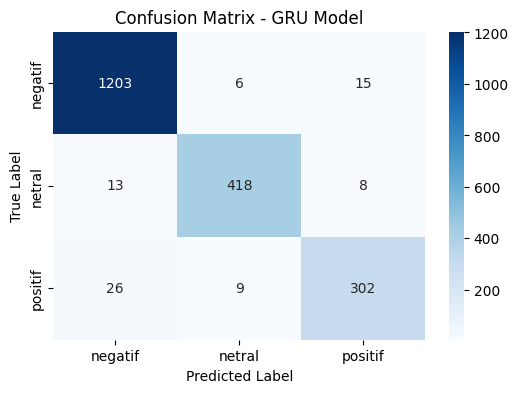

Classification Report:
               precision    recall  f1-score   support

     negatif       0.97      0.98      0.98      1224
      netral       0.97      0.95      0.96       439
     positif       0.93      0.90      0.91       337

    accuracy                           0.96      2000
   macro avg       0.95      0.94      0.95      2000
weighted avg       0.96      0.96      0.96      2000



In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Prediksi pada data uji
y_pred_gru = np.argmax(model_gru.predict(X_test_gru), axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_gru, y_pred_gru)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - GRU Model')
plt.show()

# Classification Report
print("Classification Report:\n", classification_report(y_test_gru, y_pred_gru, target_names=label_encoder.classes_))


Kelas Negatif

Recall tertinggi (0.98), model sangat baik dalam mendeteksi review negatif.

Precision 0.97, hampir semua prediksi negatif benar.

F1-score 0.98, menunjukkan keseimbangan antara precision dan recall.

Kelas Netral

Precision tertinggi (0.97), model jarang salah dalam mendeteksi sentimen netral.

Recall lebih rendah (0.95), beberapa data netral mungkin diklasifikasikan ke negatif atau positif.

F1-score tetap tinggi (0.96), performanya sangat baik.

Kelas Positif
Precision lebih rendah (0.93), ada 7% data positif yang salah diklasifikasikan.

Recall lebih rendah (0.90), model terkadang gagal mengenali data positif.

F1-score 0.91, masih cukup baik, tetapi lebih lemah dibanding kelas lain.


Evaluasi GRU + Word2Vec

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


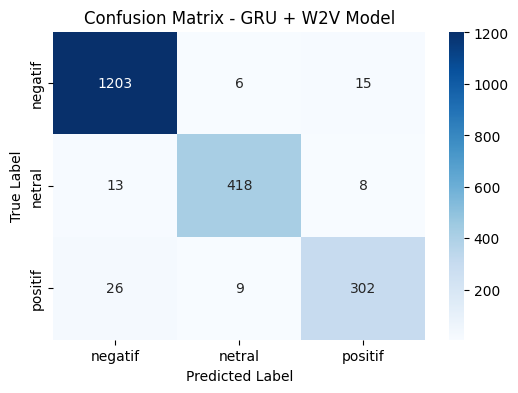

Classification Report:
               precision    recall  f1-score   support

     negatif       0.96      0.97      0.96      1834
      netral       0.91      0.96      0.93       653
     positif       0.88      0.80      0.84       513

    accuracy                           0.94      3000
   macro avg       0.92      0.91      0.91      3000
weighted avg       0.93      0.94      0.93      3000



In [30]:
# Prediksi pada data uji
y_pred_gru_w2v = np.argmax(model_gru_w2v.predict(X_test_gru_w2v), axis=1)

# Confusion Matrix
conf_matrix1 = confusion_matrix(y_test_gru_w2v, y_pred_gru_w2v)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - GRU + W2V Model')
plt.show()

# Classification Report
print("Classification Report:\n", classification_report(y_test_gru_w2v, y_pred_gru_w2v, target_names=label_encoder.classes_))

Kelas Negatif

Recall tertinggi (0.97), model sangat baik dalam mendeteksi sentimen negatif.

Precision 0.96, sebagian besar prediksi negatif akurat.

F1-score 0.96, sangat stabil dan baik.

Kelas Netral

Precision 0.91 dan Recall 0.96, model sangat baik dalam menangkap data netral.

Recall lebih tinggi dibanding precision, menunjukkan bahwa model sedikit lebih sering mengklasifikasikan data ke kelas netral.

Kelas Positif

Precision lebih rendah (0.88), model lebih sering salah mengklasifikasikan data positif.

Recall cukup rendah (0.80), mengindikasikan 20% dari data positif diklasifikasikan sebagai netral atau negatif.

F1-score 0.84, merupakan kelas dengan performa terburuk.


Evaluasi LSTM + Word Embedding

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


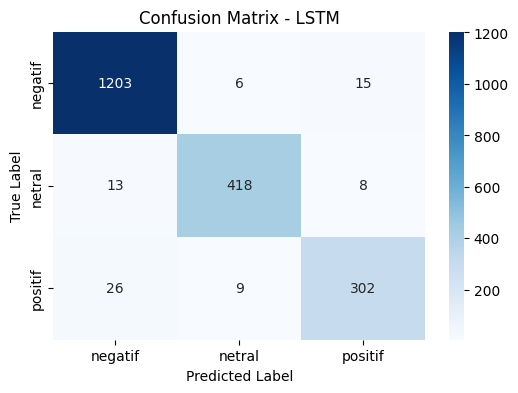

Classification Report:
               precision    recall  f1-score   support

     negatif       0.97      0.96      0.97      1224
      netral       0.94      0.93      0.94       439
     positif       0.85      0.89      0.87       337

    accuracy                           0.95      2000
   macro avg       0.92      0.93      0.93      2000
weighted avg       0.95      0.95      0.95      2000



In [31]:
# Prediksi pada data uji
y_pred_lstm = np.argmax(model_lstm.predict(X_test_lstm), axis=1)

# Confusion Matrix
conf_matrix2 = confusion_matrix(y_test_lstm, y_pred_lstm)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - LSTM')
plt.show()

# Classification Report
print("Classification Report:\n", classification_report(y_test_lstm, y_pred_lstm, target_names=label_encoder.classes_))

Kelas Negatif

Precision sangat tinggi (0.97), prediksi kelas negatif sangat akurat.

Recall 0.96, model menangkap hampir semua sampel negatif dengan baik.

F1-score 0.97, performa sangat stabil.

Kelas Netral

Precision 0.94 & Recall 0.93, model cukup akurat dalam mendeteksi sentimen netral.

F1-score 0.94, menunjukkan tidak ada masalah besar di kelas ini.

Kelas Positif
Precision 0.85, model masih cenderung memberikan prediksi positif yang kurang akurat dibanding kelas lain.

Recall 0.89, model cukup baik dalam menangkap sentimen positif, tetapi masih bisa ditingkatkan.

F1-score 0.87, performa membaik dibanding hasil sebelumnya, meskipun masih lebih rendah dari kelas lain.


# Visualisasi Model

**Visualisasi GRU Word Embedding (80/20)**

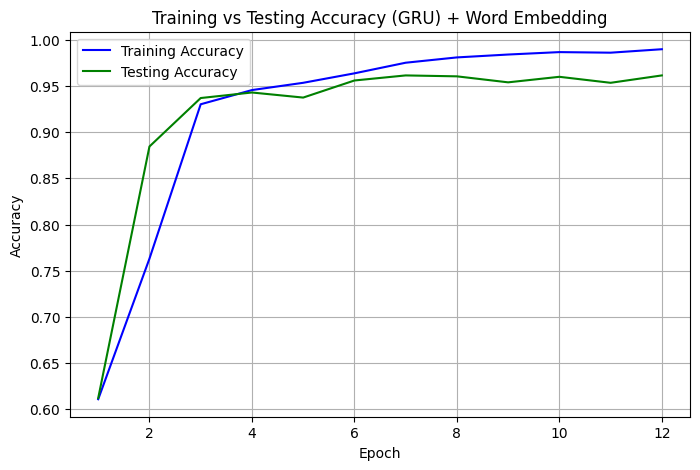

In [32]:
import matplotlib.pyplot as plt

# Ambil data akurasi dari history
train_acc = history.history["accuracy"]
test_acc = history.history["val_accuracy"]
epochs = range(1, len(train_acc) + 1)  # List jumlah epoch

# Plot grafik
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, "b-", label="Training Accuracy")
plt.plot(epochs, test_acc, "g-", label="Testing Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy (GRU) + Word Embedding")
plt.legend()
plt.grid(True)
plt.show()


Menunjukkan bahwa akurasi training meningkat pesat dalam beberapa epoch pertama dan mencapai hampir 99% pada epoch terakhir.

Akurasi testing juga meningkat dengan tren yang mirip, tetapi sedikit lebih rendah dibandingkan training.Overfitting mungkin tidak terlalu parah.
Namun, jika model mencapai hampir 100% akurasi training dan testing hanya sekitar 96%-97%, ada kemungkinan overfitting ringan.

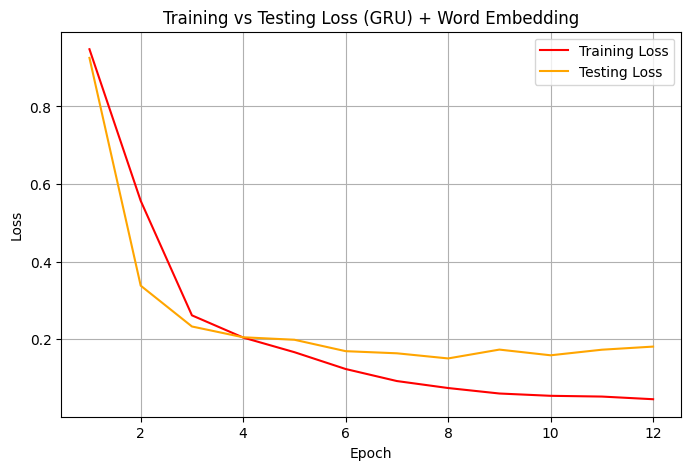

In [33]:
# Ambil data loss dari history
train_loss = history.history["loss"]
test_loss = history.history["val_loss"]

# Plot grafik
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, "r-", label="Training Loss")
plt.plot(epochs, test_loss, "orange", label="Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Testing Loss (GRU) + Word Embedding")
plt.legend()
plt.grid(True)
plt.show()


Loss menurun dengan baik pada training set, menunjukkan bahwa model belajar dengan baik.
Loss testing juga turun, tetapi terlihat stabil setelah beberapa epoch terakhir.

Gap antara loss training dan testing besar, ini bisa mengindikasikan overfitting.

**Visualisasi GRU +w2v (70/30)**

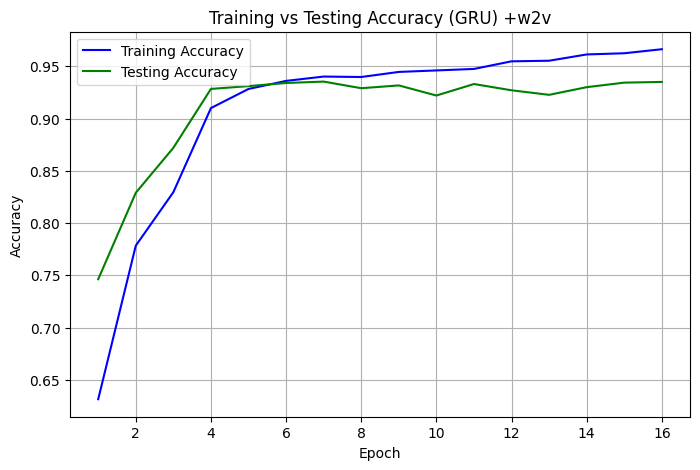

In [34]:
# Ambil data akurasi dari history
train_acc_w2v = history2.history["accuracy"]
test_acc_w2v = history2.history["val_accuracy"]
epochs_w2v = range(1, len(train_acc_w2v) + 1)  # List jumlah epoch

# Plot grafik
plt.figure(figsize=(8, 5))
plt.plot(epochs_w2v, train_acc_w2v, "b-", label="Training Accuracy")
plt.plot(epochs_w2v, test_acc_w2v, "g-", label="Testing Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy (GRU) +w2v")
plt.legend()
plt.grid(True)
plt.show()


Training Accuracy meningkat pesat di awal dan terus naik secara stabil hingga mencapai >95% pada epoch terakhir.
Testing Accuracy juga meningkat tajam pada epoch awal, mencapai sekitar 93-94%, namun kemudian mengalami sedikit fluktuasi (turun naik) pada epoch selanjutnya.

Gap antara training dan testing accuracy tetap kecil, menunjukkan bahwa model tidak mengalami overfitting yang signifikan.

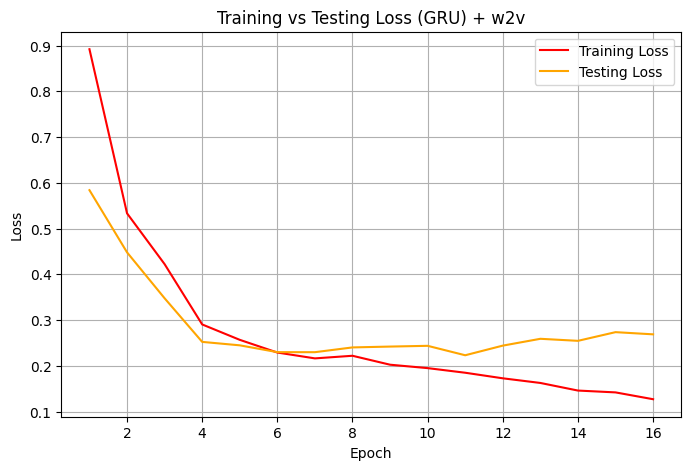

In [35]:
# Ambil data loss dari history
train_loss_w2v = history2.history["loss"]
test_loss_w2v = history2.history["val_loss"]

# Plot grafik
plt.figure(figsize=(8, 5))
plt.plot(epochs_w2v, train_loss_w2v, "r-", label="Training Loss")
plt.plot(epochs_w2v, test_loss_w2v, "orange", label="Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Testing Loss (GRU) + w2v")
plt.legend()
plt.grid(True)
plt.show()

Training Loss menurun secara stabil hingga mendekati 0.1 pada epoch terakhir, yang menunjukkan bahwa model terus belajar dengan baik.
Testing Loss juga turun secara signifikan pada awalnya, tetapi setelah sekitar epoch 6-8, terjadi sedikit fluktuasi (naik turun) yang menandakan adanya variasi dalam performa model pada data uji.

Fluktuasi Testing Loss mengindikasikan bahwa model mungkin mengalami sedikit overfitting atau generalisasi yang kurang optimal, meskipun tidak terlalu parah.

**Visulaisasi LSTM + Word Embedding (80/20)**

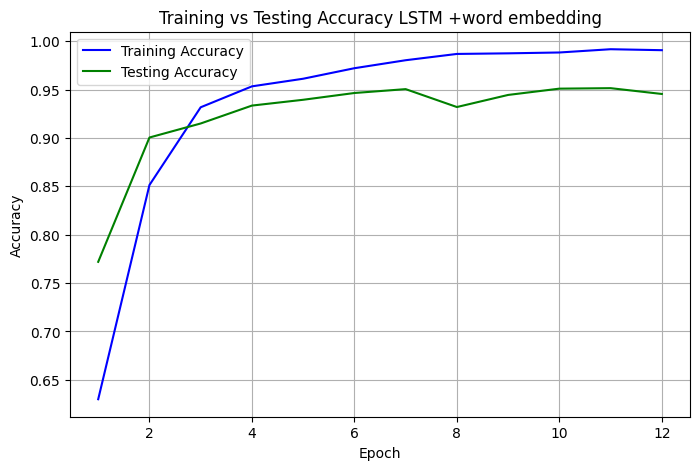

In [36]:
# Ambil data akurasi dari history
train_acc_lstm = history3.history["accuracy"]
test_acc_lstm = history3.history["val_accuracy"]
epochs_lstm = range(1, len(train_acc_lstm) + 1)  # List jumlah epoch

# Plot grafik
plt.figure(figsize=(8, 5))
plt.plot(epochs_lstm, train_acc_lstm, "b-", label="Training Accuracy")
plt.plot(epochs_lstm, test_acc_lstm, "g-", label="Testing Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy LSTM +word embedding")
plt.legend()
plt.grid(True)
plt.show()

Accuracy meningkat pesat dalam beberapa epoch pertama.
Training accuracy terus meningkat dan mendekati 100%.
Testing accuracy stabil di sekitar 94–96% setelah beberapa epoch.
Ada sedikit gap antara training dan testing accuracy, yang menunjukkan sedikit overfitting.

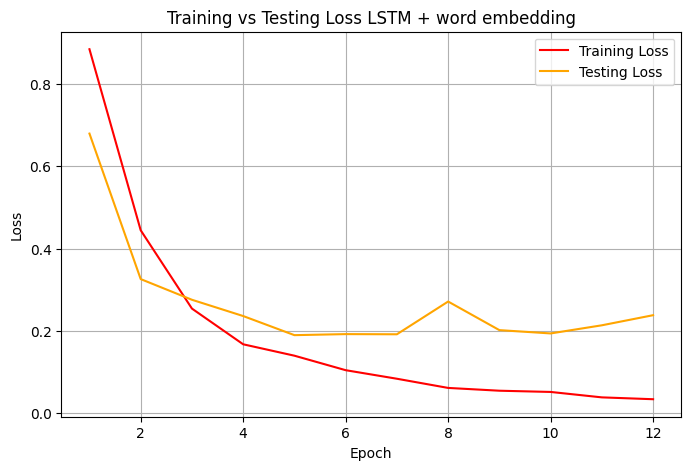

In [37]:
# Ambil data loss dari history
train_loss_lstm = history3.history["loss"]
test_loss_lstm = history3.history["val_loss"]

# Plot grafik
plt.figure(figsize=(8, 5))
plt.plot(epochs_lstm, train_loss_lstm, "r-", label="Training Loss")
plt.plot(epochs_lstm, test_loss_lstm, "orange", label="Testing Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Testing Loss LSTM + word embedding")
plt.legend()
plt.grid(True)
plt.show()

Training loss terus menurun hingga mendekati nol.
Testing loss awalnya turun tetapi kemudian sedikit meningkat di beberapa epoch terakhir.
Hal ini mengindikasikan model mulai mengalami overfitting setelah beberapa epoch.

GRU Training Accuracy: 0.9909999966621399

GRU Testing Accuracy: 0.9614999890327454

GRU + Word2Vec Training Accuracy: 0.9722856879234314

GRU + Word2Vec Testing Accuracy: 0.9350000023841858

LSTM Training Accuracy: 0.9940000176429749

LSTM Testing Accuracy: 0.9455000162124634

Kesimpulan ketiga metode:

1. GRU Word embedding (80/20)

Kelebihan: Mencapai akurasi tinggi (~96%) pada testing set. Kurva learning menunjukkan konvergensi cepat dalam beberapa epoch pertama.

Kekurangan: Ada sedikit overfitting, terlihat dari training accuracy yang lebih tinggi dibandingkan testing accuracy.
Testing loss sedikit fluktuatif di epoch akhir.

2. GRU + Word2Vec (70/30)

Kelebihan: Testing accuracy tetap stabil di sekitar 93-94% setelah beberapa epoch.
Model lebih generalizable dibanding GRU + Word Embedding, karena training accuracy tidak terlalu tinggi.

Kekurangan:
Testing loss masih sedikit fluktuatif.
Akurasi sedikit lebih rendah dibandingkan GRU + Word Embedding.

3. LSTM + Word Embedding (80/20)

Kelebihan: Performa tertinggi dengan testing accuracy sekitar 94-96%.
Kurva learning cukup stabil setelah beberapa epoch.

Kekurangan:

Overfitting cukup jelas, karena training accuracy hampir 100%, sementara testing accuracy stagnan.
Testing loss mulai naik di epoch akhir.


Ketiga metode memiliki akurasi lebih dari 92% akan tetapi model terbaik pada pelatihan sentimen analisis ini yaitu menggunakan deep learning GRU model dengan fitur ekstraksi Word Embedding (train data 80% & test data 20%) hal ini berdasarkan grafik yang paling baik karena tidak mengalami overfitting

#Kesimpulan

Distribusi Kelas Negatif sebanyak 6119 sentimen

Kelas Netral sebanyak 2104 sentimen

Kelas Positif sebanyak 1777 sentimen

Jadi, terdapat 54.41% sentimen negatif, 28.15% sentimen netral dan 17.44% sentimen positif untuk applikasi game mobile legend

Analisis per aspek:

1.Gameplay

Gameplay Total ulasan: 5.640

Sentimen Positif: 1.472 (26.10%)

Sentimen Negatif: 4.168 (73.90%)

2. Performa

Performa Total ulasan: 1.570
Sentimen Positif: 362 (23.06%)

Sentimen Negatif: 1.208 (76.94%)

3. Grafik

Total ulasan: 180

Sentimen Positif: 35 (19.44%)

Sentimen Negatif: 145 (80.56%)

Kesimpulan:

Gameplay dan Performa adalah dua aspek utama yang paling banyak dikritik.
Mayoritas ulasan negatif terhadap gameplay mungkin terkait mekanisme game, balancing, atau sistem matchmaking. Performa buruk juga menjadi masalah utama, dengan kemungkinan keluhan tentang lag, koneksi server, atau bug.

Grafik adalah aspek yang paling sedikit dibahas, tetapi memiliki persentase negatif tertinggi.
Ini menunjukkan bahwa meskipun grafik bukan prioritas utama pemain, mereka yang membahasnya cenderung kurang puas.

Secara keseluruhan, tingkat sentimen negatif lebih tinggi dibanding positif di semua aspek.
Ini menunjukkan bahwa banyak pemain Mobile Legends merasa ada banyak hal yang perlu diperbaiki dalam game, terutama dari segi gameplay dan performa.

Saran untuk meningkatkan performa game & para pengguna:

- pengembang melakukan perbaikan balance, mode permainan dan menambahkan fitur terbaru

- Pengembang harus mengatasi masalah lag, bug, dan crash untuk meningkatkan pengalaman bermain para pengguna

- Pengembang lebih fokus pada perbaikan performa dibandingkan grafik visual.

**Metode Terbaik**


SVM + TF-IDF Accuracy: 95.15%

XGBoost + TF-IDF Testing Accuracy: 96.95%

GRU Training Accuracy: 0.99%

GRU Testing Accuracy: 0.96%

GRU + Word2Vec Training Accuracy: 97.22%

GRU + Word2Vec Testing Accuracy: 93.50%

LSTM Training Accuracy: 99.40%

LSTM Testing Accuracy: 94.55%

Pada Model klasik SVM + TF-IDF dengan XGBoost + TF-IDF, XGBoost memiliki akurasi terbaik dengan overfitting terlihat paling rendah dibandingkan dengan SVM+TF-IDF. Selain itu model XGBoost dengan ekstraksi fitur TF-IDF (80/20) juga memiliki waktu training yang sangat cepat

Pada model deep learning GRU + Word Embedding memiliki akurasi sebesar 93.50% dengan overfitting sedikit dan memiliki F1-score 0.93, akan tetapi memiliki waktu training yang lama dibandingkan model klasik sehingga membutuhkan GPU lebih besar.


Kesimpulan:

XGBoost + TF-IDF adalah model terbaik dalam hal akurasi, F1-score, dan stabilitas.

SVM juga cukup baik, tetapi XGBoost lebih unggul dalam kelas positif dan lebih sedikit overfitting.

Deep learning tidak terlalu unggul dibandingkan model klasik dalam kasus ini.

GRU dengan Word2Vec memiliki performa paling rendah dalam eksperimen ini.


Rekomendasi:

Gunakan XGBoost +TF-IDF jika menggunakan akurasi yang tinggi dengan training yang cepat

Jika menggunakan dataset lebih dari 10.000 sampel, maka mungkin deep learning akan jauh lebih unggul.

In [38]:
!pip freeze > requirements.txt
